<a href="https://colab.research.google.com/github/kelvin-yg98/Kelvin-Programming/blob/main/Building_a_Leakage_Safe_Preprocessing_Pipeline_in_Scikit_Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder, TargetEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Set plot style
sns.set_theme(style="whitegrid")

In [14]:
# ==========================================
# STEP 1: DATA INGESTION & FEATURE GROUPING
# ==========================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

try:
    df = pd.read_csv(url, names=column_names, skipinitialspace=True, na_values="?")
    df["income"] = (df["income"].str.strip(". ") == ">50K").astype(int)
except Exception as e:
    print(f"Dataset download failed ({e}). Generating synthetic Adult dataset instead...")
    np.random.seed(42)
    n_samples = 5000
    df = pd.DataFrame({
        "capital-gain": np.where(np.random.rand(n_samples) < 0.9, 0, np.random.exponential(7000, n_samples)),
        "hours-per-week": np.random.normal(40, 10, n_samples).clip(10, 80),
        "marital-status": np.random.choice(["Never-married", "Married-civ-spouse", "Divorced"], n_samples),
        "occupation": np.random.choice(["Exec-managerial", "Craft-repair", "Sales", "Prof-specialty", "Other-service"], n_samples),
        "native-country": np.random.choice(["United-States", "Mexico", "Philippines", "Germany", "Canada"], n_samples),
        "income": np.random.choice([0, 1], n_samples, p=[0.75, 0.25])
    })

# Select streamlined feature set
selected_cols = [
    "capital-gain", "hours-per-week",
    "marital-status",
    "occupation", "native-country",
    "income"
]
df_clean = df[selected_cols].copy()

# Define column groups
num_cols = ["capital-gain", "hours-per-week"]
cat_low_card = ["marital-status"]
cat_high_card = ["occupation", "native-country"]

X = df_clean[num_cols + cat_low_card + cat_high_card]
y = df_clean["income"]

In [16]:
# ==========================================
# STEP 2: BUILD PER-TYPE TRANSFORMERS
# ==========================================
# 1. Numerical branch
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('yeo_johnson', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

# 2. Low-cardinality categorical branch
cat_low_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# 3. High-cardinality categorical branch
cat_high_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('target_enc', TargetEncoder(smooth='auto', cv=5))
])

# Combine branches into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat_low', cat_low_pipeline, cat_low_card),
        ('cat_high', cat_high_pipeline, cat_high_card)
    ],
    remainder='drop'
)

In [17]:
# ==========================================
# STEP 3: FULL PIPELINE & CROSS-VALIDATION
# ==========================================
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clean_results = cross_validate(
    full_pipeline,
    X,
    y,
    cv=cv,
    scoring=['accuracy', 'roc_auc'],
    return_train_score=True,
    n_jobs=-1
)

print("\n" + "="*50)
print("LEAK-FREE PIPELINE CROSS-VALIDATION PERFORMANCE")
print("="*50)
print(f"Mean Train ROC-AUC : {clean_results['train_roc_auc'].mean():.4f} ± {clean_results['train_roc_auc'].std():.4f}")
print(f"Mean Test ROC-AUC  : {clean_results['test_roc_auc'].mean():.4f} ± {clean_results['test_roc_auc'].std():.4f}")
print(f"Mean Test Accuracy : {clean_results['test_accuracy'].mean():.4f} ± {clean_results['test_accuracy'].std():.4f}")


LEAK-FREE PIPELINE CROSS-VALIDATION PERFORMANCE
Mean Train ROC-AUC : 0.9042 ± 0.0016
Mean Test ROC-AUC  : 0.8979 ± 0.0032
Mean Test Accuracy : 0.8470 ± 0.0030


In [18]:
# ==========================================
# STEP 4: TARGET ENCODING LEAKAGE DEMO
# ==========================================
class NaiveGlobalTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols):
        self.cat_cols = cat_cols
        self.encoder = TargetEncoder(smooth='auto', cv=5)

    def fit_transform_global(self, X, y):
        X_encoded = X.copy()
        X_encoded[self.cat_cols] = self.encoder.fit_transform(X[self.cat_cols], y)
        return X_encoded

# Simulate improper global target encoding (LEAK)
naive_encoder = NaiveGlobalTargetEncoder(cat_cols=cat_high_card)
X_leaked = naive_encoder.fit_transform_global(X, y)

leaked_results = cross_validate(
    Pipeline([
        ('num_low_prep', ColumnTransformer([
            ('num', num_pipeline, num_cols),
            ('cat_low', cat_low_pipeline, cat_low_card)
        ], remainder='passthrough')),
        ('classifier', HistGradientBoostingClassifier(random_state=42))
    ]),
    X_leaked, y, cv=cv, scoring=['accuracy', 'roc_auc'], return_train_score=True, n_jobs=-1
)

metrics_df = pd.DataFrame({
    'Approach': ['Leaked (Global Encoding)', 'Proper (Pipeline Enclosed)'],
    'Train ROC-AUC': [leaked_results['train_roc_auc'].mean(), clean_results['train_roc_auc'].mean()],
    'Test ROC-AUC': [leaked_results['test_roc_auc'].mean(), clean_results['test_roc_auc'].mean()],
    'Generalization Gap': [
        leaked_results['train_roc_auc'].mean() - leaked_results['test_roc_auc'].mean(),
        clean_results['train_roc_auc'].mean() - clean_results['test_roc_auc'].mean()
    ]
})

print("\n" + "="*50)
print("TARGET LEAKAGE EXPERIMENT RESULTS")
print("="*50)
print(metrics_df.to_string(index=False))


TARGET LEAKAGE EXPERIMENT RESULTS
                  Approach  Train ROC-AUC  Test ROC-AUC  Generalization Gap
  Leaked (Global Encoding)       0.909743      0.898502            0.011241
Proper (Pipeline Enclosed)       0.904242      0.897872            0.006371


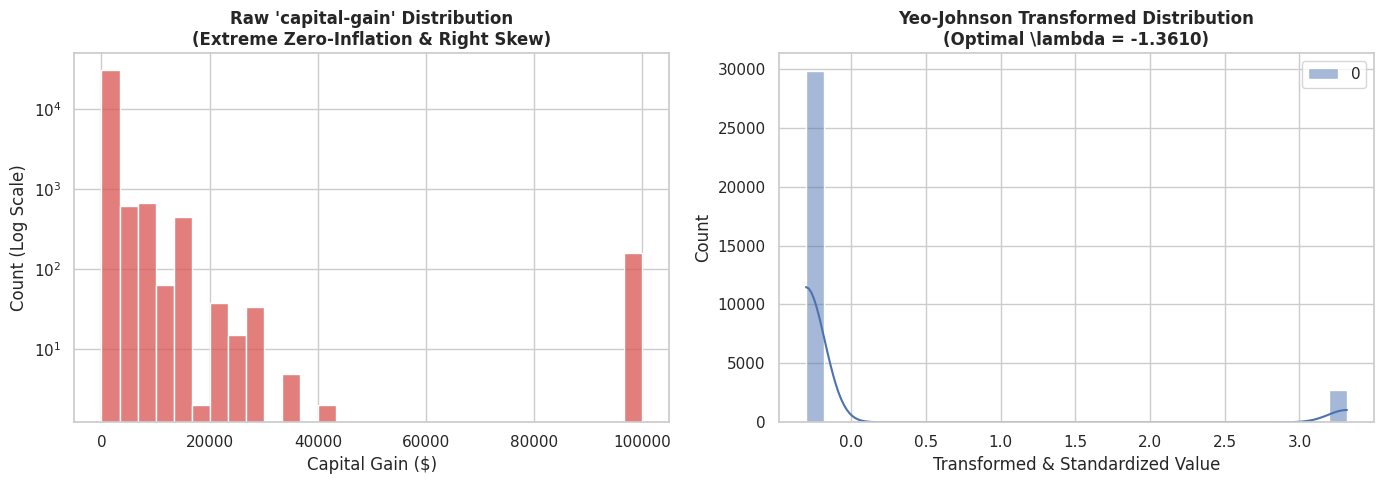


DISTRIBUTION TRANSFORM METRICS
Raw Skewness       : 11.9538
Transformed Skewness: 3.0163
Optimal Lambda (λ) : -1.3610


In [20]:
# ==========================================
# STEP 5: VISUALIZE YEO-JOHNSON TRANSFORM
# ==========================================
pt = PowerTransformer(method='yeo-johnson')
capital_gain_trans = pt.fit_transform(df_clean[['capital-gain']])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Distribution Plot
sns.histplot(df_clean['capital-gain'], kde=False, ax=axes[0], color='#D9534F', bins=30)
axes[0].set_title("Raw 'capital-gain' Distribution\n(Extreme Zero-Inflation & Right Skew)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Capital Gain ($)")
axes[0].set_ylabel("Count (Log Scale)")
axes[0].set_yscale('log')

# Transformed Distribution Plot (Escaped \\lambda fix applied)
sns.histplot(capital_gain_trans, kde=True, ax=axes[1], color='#0275D8', bins=30)
axes[1].set_title(
    f"Yeo-Johnson Transformed Distribution\n(Optimal \\lambda = {pt.lambdas_[0]:.4f})",
    fontsize=12,
    fontweight='bold'
)
axes[1].set_xlabel("Transformed & Standardized Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("DISTRIBUTION TRANSFORM METRICS")
print("="*50)
print(f"Raw Skewness       : {df_clean['capital-gain'].skew():.4f}")
print(f"Transformed Skewness: {pd.Series(capital_gain_trans.flatten()).skew():.4f}")
print(f"Optimal Lambda (λ) : {pt.lambdas_[0]:.4f}")